# 🗺️ Land Cover & Elevation
**ESIIL STARS 2026 · SICK**

**Prerequisites:** Complete Notebooks 1 and 2 first.

In this notebook you will:
1. Explore NLCD land cover classification for CSU campus
2. Detect land cover change between 2001 and 2021
3. Load the 3DEP digital elevation model
4. Combine land cover and elevation — a preview of the full Front Range analysis

**⏱ Estimated time:** 40–55 minutes

⚠️ **Branch check** — before running any cells, confirm you are on **your own branch**, not `main`.
In VS Code, open the **Source Control** panel (branch icon in the left sidebar).

1. Look at the current branch name in the Source Control view or status bar."
2. If you are on `main`, click the branch name in the status bar."
3. Choose **Create new branch...** and name it `yourname`."
4. Make sure that new branch is now selected before running notebook cells."

---
## Setup

In [1]:
# ── Standard imports ─────────────────────────────────────────────────
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from PIL import Image
from io import BytesIO
from IPython.display import display, HTML

# ── GEE display helper ────────────────────────────────────────────────
def show_map(m):
    """Reliably display a geemap Map in Codespaces."""
    try:
        display(m)
    except Exception:
        display(HTML(m.to_html()))

print("✅ Imports successful!")

✅ Imports successful!


In [2]:
# ⚠️ Replace with YOUR project ID (same one from Notebook 1)
PROJECT_ID = 'ee-xinranzhou2059'

ee.Authenticate()
ee.Initialize(project=PROJECT_ID)
print(f"✅ Earth Engine ready — project: {PROJECT_ID}")

✅ Earth Engine ready — project: ee-xinranzhou2059


In [3]:
# ── Study area: CSU campus ────────────────────────────────────────────
csu_lon, csu_lat = -105.0844, 40.5734
csu_aoi = ee.Geometry.Point([csu_lon, csu_lat]).buffer(1000).bounds()

# ── Landsat scale-factor helper ───────────────────────────────────────
def apply_scale_factors(image):
    optical = image.select('SR_B.*').multiply(0.0000275).add(-0.2)
    thermal = image.select('ST_B.*').multiply(0.00341802).add(149.0)
    return image.addBands(optical, overwrite=True) \
                .addBands(thermal, overwrite=True)

# ── Thumbnail helper (for saving static figures) ──────────────────────
def get_ee_thumbnail(image, vis_params, region, size=512):
    """Fetch a GEE image as a PIL Image for matplotlib/savefig."""
    params = {**vis_params, 'region': region.getInfo(),
              'dimensions': size, 'format': 'png'}
    url = image.getThumbURL(params)
    return Image.open(BytesIO(requests.get(url).content))

print("✅ Study area and helpers defined!")

✅ Study area and helpers defined!


---
## Part 5: Land Cover with NLCD

### What is NLCD?

The **National Land Cover Database (NLCD)** classifies every 30 m pixel across the contiguous US into standardized land cover categories — updated roughly every two years from 1985 to 2023. In GEE it's available as an `ee.ImageCollection` where each image is one year.

For our Front Range project, NLCD is the primary dataset: we'll measure how the area of forest, developed land, and grassland pixels changes with elevation over 39 years. This notebook introduces you to the dataset at campus scale first.

In [4]:
# Load NLCD for two years
nlcd_2001 = (ee.ImageCollection('USGS/NLCD_RELEASES/2019_REL/NLCD')
             .filter(ee.Filter.eq('system:index', '2001'))
             .first().select('landcover').clip(csu_aoi))

nlcd_2021 = (ee.ImageCollection('USGS/NLCD_RELEASES/2021_REL/NLCD')
             .filter(ee.Filter.eq('system:index', '2021'))
             .first().select('landcover').clip(csu_aoi))

# GEE knows NLCD's color palette — no vis_params needed
Map5 = geemap.Map(center=[csu_lat, csu_lon], zoom=14)
Map5.addLayer(nlcd_2001, {}, 'NLCD 2001')
Map5.addLayer(nlcd_2021, {}, 'NLCD 2021')
Map5.add_legend(title='NLCD Land Cover', builtin_legend='NLCD')
show_map(Map5)

Map(center=[40.5734, -105.0844], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

### NLCD class codes — the ones you'll see most in Colorado

| Code | Class | Typical color |
|------|-------|--------------|
| 21–24 | Developed (Open → High intensity) | Pink → Dark red |
| 41 | Deciduous Forest | Light green |
| 42 | Evergreen Forest | Dark green |
| 52 | Shrub/Scrub | Tan |
| 71 | Grassland/Herbaceous | Yellow-green |
| 81 | Pasture/Hay | Yellow |
| 82 | Cultivated Crops | Brown |

Toggle between 2001 and 2021 on the map. Can you see development expanding around campus?

### Count pixels per class

`reduceRegion()` with `frequencyHistogram()` is a GEE reducer that counts how many pixels of each integer value fall inside your AOI. This is the exact approach we'll use at the Front Range scale.

In [5]:
def count_classes(nlcd_image, year):
    """Return a dict of {class_code: pixel_count} for an NLCD image."""
    result = nlcd_image.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=csu_aoi, scale=30, maxPixels=1e9
    ).getInfo()
    counts = result['landcover']
    print(f"\n--- NLCD {year} (top classes) ---")
    for code, n in sorted(counts.items(), key=lambda x: -x[1])[:8]:
        print(f"  Class {code}: {n:,} pixels")
    return counts

counts_2001 = count_classes(nlcd_2001, 2001)
counts_2021 = count_classes(nlcd_2021, 2021)


--- NLCD 2001 (top classes) ---
  Class 22: 1,969.7647058823527 pixels
  Class 23: 1,125.7686274509804 pixels
  Class 21: 845.4274509803919 pixels
  Class 24: 484.00784313725495 pixels

--- NLCD 2021 (top classes) ---
  Class 22: 1,806.2666666666664 pixels
  Class 23: 1,337.5058823529412 pixels
  Class 21: 658.3490196078429 pixels
  Class 24: 622.8470588235296 pixels


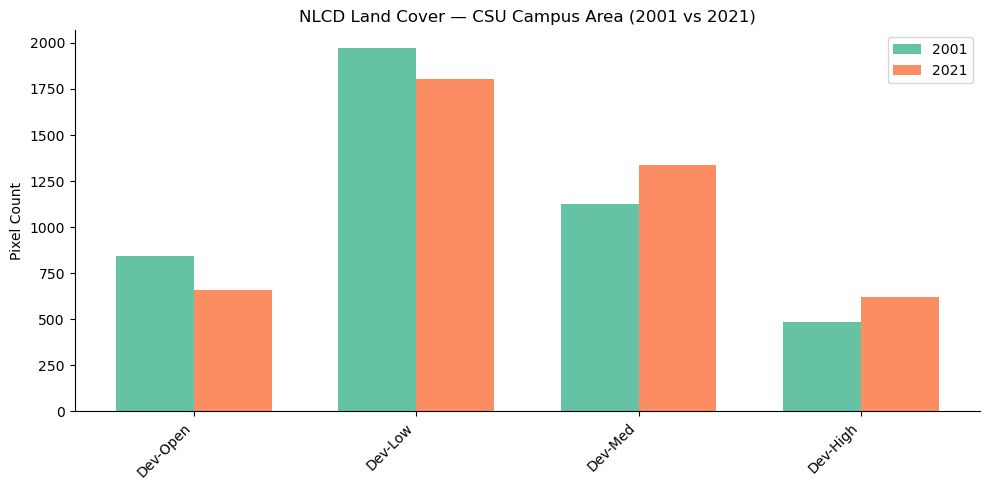

✅ Saved → figures/csu_nlcd_comparison.png


In [6]:
# Bar chart: 2001 vs 2021 side by side
nlcd_names = {
    '11':'Water','21':'Dev-Open','22':'Dev-Low','23':'Dev-Med','24':'Dev-High',
    '41':'Deciduous','42':'Evergreen','52':'Shrub','71':'Grassland',
    '81':'Pasture','82':'Crops'
}
all_classes = sorted(set(counts_2001) | set(counts_2021))
df = pd.DataFrame({
    'Class': [nlcd_names.get(c, f'Other ({c})') for c in all_classes],
    '2001':  [counts_2001.get(c, 0) for c in all_classes],
    '2021':  [counts_2021.get(c, 0) for c in all_classes],
})

fig, ax = plt.subplots(figsize=(10, 5))
x, w = range(len(df)), 0.35
ax.bar([i - w/2 for i in x], df['2001'], w, label='2001', color='#66c2a5')
ax.bar([i + w/2 for i in x], df['2021'], w, label='2021', color='#fc8d62')
ax.set_xticks(x); ax.set_xticklabels(df['Class'], rotation=45, ha='right')
ax.set_ylabel('Pixel Count')
ax.set_title('NLCD Land Cover — CSU Campus Area (2001 vs 2021)')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/csu_nlcd_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved → figures/csu_nlcd_comparison.png")

### 🏋️ Exercise 3

**3a.** Expand the AOI to a **5 km buffer** and re-run the class counts. Do you see more agricultural land?
```python
csu_wide = ee.Geometry.Point([csu_lon, csu_lat]).buffer(5000).bounds()
```

**3b.** Which class **increased** the most between 2001 and 2021? Which **decreased** the most?
Add a code cell that computes and prints the answer (don't just eyeball the chart).

In [7]:
# ✏️ Exercise 3a — 5 km AOI class counts

# Expand AOI to 5 km around CSU
csu_wide = ee.Geometry.Point([csu_lon, csu_lat]).buffer(5000).bounds()

# Re-load NLCD and clip to the wider AOI
nlcd_2001_wide = (
    ee.ImageCollection('USGS/NLCD_RELEASES/2019_REL/NLCD')
    .filter(ee.Filter.eq('system:index', '2001'))
    .first()
    .select('landcover')
    .clip(csu_wide)
)

nlcd_2021_wide = (
    ee.ImageCollection('USGS/NLCD_RELEASES/2021_REL/NLCD')
    .filter(ee.Filter.eq('system:index', '2021'))
    .first()
    .select('landcover')
    .clip(csu_wide)
)

def count_classes_wide(nlcd_image, year):
    """Return a dict of {class_code: pixel_count} for a wider AOI."""
    result = nlcd_image.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=csu_wide,
        scale=30,
        maxPixels=1e9
    ).getInfo()
    
    counts = result['landcover']
    
    print(f"\n--- NLCD {year} for 5 km AOI (top classes) ---")
    for code, n in sorted(counts.items(), key=lambda x: -x[1])[:10]:
        name = nlcd_names.get(str(code), f"Other ({code})")
        print(f"  Class {code} ({name}): {n:,.0f} pixels")
    
    return counts

counts_2001_wide = count_classes_wide(nlcd_2001_wide, 2001)
counts_2021_wide = count_classes_wide(nlcd_2021_wide, 2021)

# Check agricultural land: Pasture/Hay = 81, Cultivated Crops = 82
ag_2001 = counts_2001_wide.get('81', 0) + counts_2001_wide.get('82', 0)
ag_2021 = counts_2021_wide.get('81', 0) + counts_2021_wide.get('82', 0)

print("\n--- Agricultural land in 5 km AOI ---")
print(f"2001 agriculture pixels: {ag_2001:,.0f}")
print(f"2021 agriculture pixels: {ag_2021:,.0f}")

if ag_2021 > 0 or ag_2001 > 0:
    print("Yes, the 5 km AOI includes more agricultural land than the smaller campus AOI.")
else:
    print("No obvious agricultural classes were detected in the 5 km AOI.")



--- NLCD 2001 for 5 km AOI (top classes) ---
  Class 22 (Dev-Low): 34,018 pixels
  Class 23 (Dev-Med): 17,360 pixels
  Class 21 (Dev-Open): 16,751 pixels
  Class 71 (Grassland): 12,106 pixels
  Class 82 (Crops): 8,269 pixels
  Class 24 (Dev-High): 5,568 pixels
  Class 81 (Pasture): 4,728 pixels
  Class 11 (Water): 4,263 pixels
  Class 95 (Other (95)): 4,081 pixels
  Class 90 (Other (90)): 1,925 pixels

--- NLCD 2021 for 5 km AOI (top classes) ---
  Class 22 (Dev-Low): 34,582 pixels
  Class 23 (Dev-Med): 21,871 pixels
  Class 21 (Dev-Open): 16,129 pixels
  Class 71 (Grassland): 10,898 pixels
  Class 24 (Dev-High): 7,333 pixels
  Class 82 (Crops): 4,943 pixels
  Class 11 (Water): 4,052 pixels
  Class 81 (Pasture): 3,872 pixels
  Class 95 (Other (95)): 3,688 pixels
  Class 90 (Other (90)): 1,767 pixels

--- Agricultural land in 5 km AOI ---
2001 agriculture pixels: 12,998
2021 agriculture pixels: 8,816
Yes, the 5 km AOI includes more agricultural land than the smaller campus AOI.


In [ ]:
# After expanding the AOI to a 5 km buffer, more agricultural land appears in the land-cover counts. The wider AOI includes both Pasture/Hay (Class 81) and Cultivated Crops (Class 82), which were not as prominent in the smaller campus-only AOI. In 2001, the 5 km AOI contains 12,998 agricultural pixels, while in 2021 it contains 8,816 agricultural pixels. This suggests that the area surrounding campus includes agricultural land, but the amount of agricultural land decreased between 2001 and 2021.

In [8]:
# # ✏️ Exercise 3b — Largest increase and decrease between 2001 and 2021

# Use the original smaller campus AOI counts from earlier:
# counts_2001 and counts_2021

all_classes = sorted(set(counts_2001.keys()) | set(counts_2021.keys()), key=lambda x: int(x))

changes = {}

for code in all_classes:
    count_2001 = counts_2001.get(code, 0)
    count_2021 = counts_2021.get(code, 0)
    change = count_2021 - count_2001
    changes[code] = change

largest_increase_code = max(changes, key=changes.get)
largest_decrease_code = min(changes, key=changes.get)

largest_increase_name = nlcd_names.get(str(largest_increase_code), f"Other ({largest_increase_code})")
largest_decrease_name = nlcd_names.get(str(largest_decrease_code), f"Other ({largest_decrease_code})")

print("--- Largest NLCD class changes from 2001 to 2021 ---")
print(
    f"Largest increase: Class {largest_increase_code} ({largest_increase_name}) "
    f"with +{changes[largest_increase_code]:,.0f} pixels"
)
print(
    f"Largest decrease: Class {largest_decrease_code} ({largest_decrease_name}) "
    f"with {changes[largest_decrease_code]:,.0f} pixels"
)

print("\nAll class changes:")
for code, change in sorted(changes.items(), key=lambda x: x[1], reverse=True):
    name = nlcd_names.get(str(code), f"Other ({code})")
    print(f"  Class {code} ({name}): {change:+,.0f} pixels")


--- Largest NLCD class changes from 2001 to 2021 ---
Largest increase: Class 23 (Dev-Med) with +212 pixels
Largest decrease: Class 21 (Dev-Open) with -187 pixels

All class changes:
  Class 23 (Dev-Med): +212 pixels
  Class 24 (Dev-High): +139 pixels
  Class 22 (Dev-Low): -163 pixels
  Class 21 (Dev-Open): -187 pixels


In [ ]:
# Between 2001 and 2021, the land-cover class that increased the most was Developed Medium Intensity (Class 23), with an increase of 212 pixels. The class that decreased the most was Developed Open Space (Class 21), with a decrease of 187 pixels. Developed High Intensity (Class 24) also increased, while Developed Low Intensity (Class 22) decreased. This suggests that parts of the CSU campus area became more intensively developed over time, with some open or lower-intensity developed areas shifting toward medium- or high-intensity development.

---
## Part 6: Elevation with the USGS 3DEP DEM

### What is a DEM?

A **Digital Elevation Model (DEM)** is a raster where every pixel value is the terrain elevation in metres above sea level. The USGS 3D Elevation Program (3DEP) provides a 10 m resolution DEM for the entire US, available in GEE at `'USGS/3DEP/10m'`.

For our project, elevation is the key structuring variable — we'll divide the Front Range into 100 m elevation bands and ask how forest cover in each band has changed over 39 years.

In [9]:
# Use a wider AOI to see the foothills rising west of campus
foothills_aoi = ee.Geometry.Point([csu_lon, csu_lat]).buffer(15000).bounds()

dem = ee.Image('USGS/3DEP/10m').clip(foothills_aoi)

elev_vis = {
    'min': 1500, 'max': 2200,
    'palette': ['#2b83ba', '#abdda4', '#ffffbf', '#fdae61', '#d7191c']
}

Map6 = geemap.Map(center=[csu_lat, csu_lon - 0.05], zoom=12)
Map6.addLayer(dem, elev_vis, 'Elevation (m)')
Map6.add_colorbar(elev_vis, label='Elevation (m)')
show_map(Map6)

Map(center=[40.5734, -105.1344], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

### Derive slope from the DEM

In [10]:
slope = ee.Terrain.slope(dem)

slope_vis = {'min': 0, 'max': 30,
             'palette': ['#f7fcf5', '#74c476', '#238b45', '#00441b']}

Map7 = geemap.Map(center=[csu_lat, csu_lon - 0.05], zoom=12)
Map7.addLayer(slope, slope_vis, 'Slope (degrees)')
Map7.add_colorbar(slope_vis, label='Slope (degrees)')
show_map(Map7)

Map(center=[40.5734, -105.1344], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

---
## Part 7: Combining DEM + NLCD — A Preview of the Front Range Analysis

This is the core analytical move for our project. We'll sample points that have both an elevation value and a land cover class, then ask: **"How does land cover vary with elevation?"**

At the Front Range scale we'll do this across 39 years. Here we do it once for 2021 at campus scale.

In [11]:
# Load NLCD 2021 for the wider foothills AOI
nlcd_foothills = (ee.ImageCollection('USGS/NLCD_RELEASES/2021_REL/NLCD')
                  .filter(ee.Filter.eq('system:index', '2021'))
                  .first().select('landcover').clip(foothills_aoi))

# Stack DEM + NLCD into a single multi-band image, then sample
combined = dem.addBands(nlcd_foothills)

samples = combined.sample(
    region=foothills_aoi, scale=30,
    numPixels=2000, seed=42, geometries=False
)

df_samples = geemap.ee_to_df(samples, remove_geom=False)
print(f"Sampled {len(df_samples)} points")
df_samples.head()

Sampled 2000 points


,geo,elevation,landcover
0,None,1649.561035,11
1,None,1686.332275,52
2,None,1509.971924,23
3,None,1530.871826,23
4,None,1536.269165,82


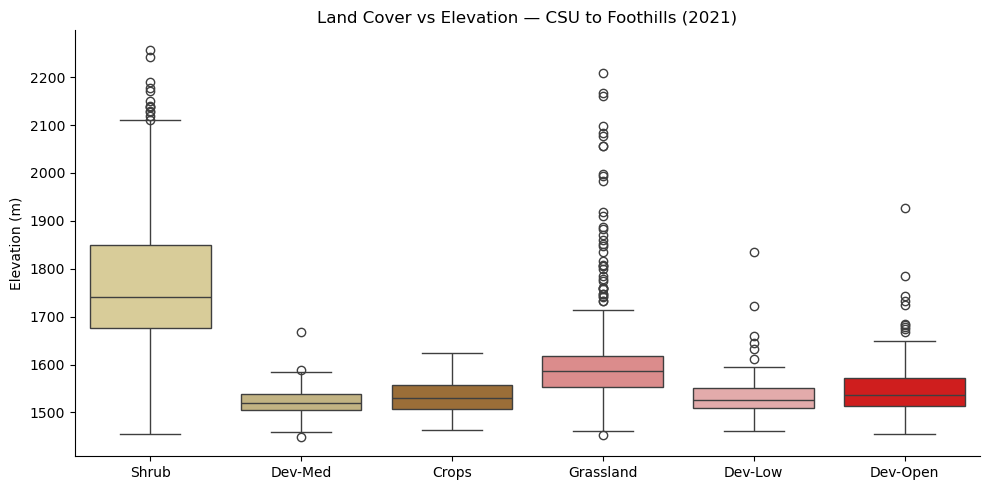

✅ Saved → figures/csu_landcover_vs_elevation.png


In [12]:
nlcd_name_map = {
    11:'Water', 21:'Dev-Open', 22:'Dev-Low', 23:'Dev-Med', 24:'Dev-High',
    41:'Deciduous', 42:'Evergreen', 43:'Mixed Forest',
    52:'Shrub', 71:'Grassland', 81:'Pasture', 82:'Crops', 90:'Wetland'
}
nlcd_color_map = {
    'Dev-Open':'#eda1a1','Dev-Low':'#e87f7f','Dev-Med':'#ed0000','Dev-High':'#ab0000',
    'Evergreen':'#1c6330','Deciduous':'#68ab63','Grassland':'#e3d28e',
    'Shrub':'#ccb879','Pasture':'#dbd93d','Crops':'#ab7028'
}

df_samples['Land Cover'] = df_samples['landcover'].map(nlcd_name_map)
df_samples = df_samples.dropna(subset=['Land Cover'])

top_classes = df_samples['Land Cover'].value_counts().head(6).index.tolist()
df_plot = df_samples[df_samples['Land Cover'].isin(top_classes)]
colors = [nlcd_color_map.get(c, '#999999') for c in top_classes]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_plot, x='Land Cover', y='elevation', palette=colors, ax=ax)
ax.set_ylabel('Elevation (m)'); ax.set_xlabel('')
ax.set_title('Land Cover vs Elevation — CSU to Foothills (2021)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/csu_landcover_vs_elevation.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved → figures/csu_landcover_vs_elevation.png")

### 🏋️ Exercise 4

**4a.** Make an **elevation histogram** of the sampled points. What is the elevation range in the 15 km study area?
```python
plt.hist(df_samples['elevation'], bins=30, color='steelblue', edgecolor='white')
```

**4b.** Which land cover class sits at the **highest median elevation** in the boxplot? Does that make ecological sense given what you know about the Front Range? Write your answer as a markdown cell.

**4c. Stretch:** Re-do the boxplot but split by **slope** instead of land cover. Create a new column:
```python
# You'll need to sample slope the same way as elevation — add slope as a band in 'combined'
```
Does forest occur on steeper slopes than grassland?

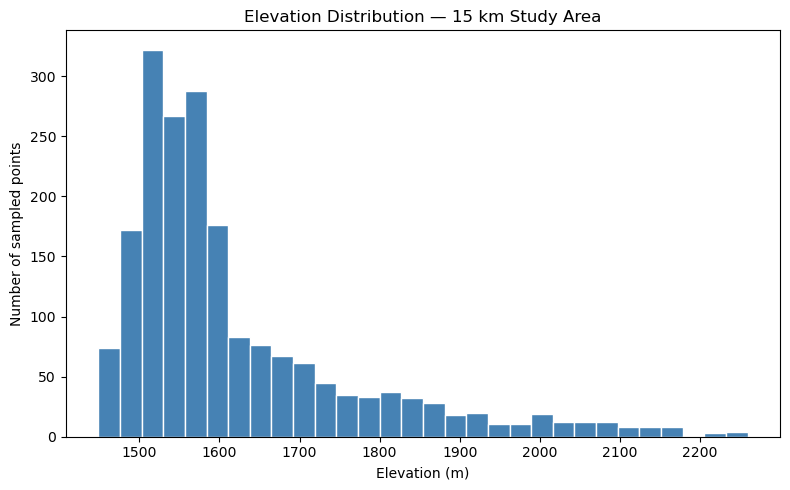

Minimum elevation: 1448.8 m
Maximum elevation: 2259.4 m
Elevation range: 810.6 m


In [13]:
# ✏️ Exercise 4a — Elevation histogram

plt.figure(figsize=(8, 5))
plt.hist(df_samples['elevation'], bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Elevation (m)')
plt.ylabel('Number of sampled points')
plt.title('Elevation Distribution — 15 km Study Area')
plt.tight_layout()
plt.savefig('figures/csu_elevation_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

elev_min = df_samples['elevation'].min()
elev_max = df_samples['elevation'].max()
elev_range = elev_max - elev_min

print(f"Minimum elevation: {elev_min:.1f} m")
print(f"Maximum elevation: {elev_max:.1f} m")
print(f"Elevation range: {elev_range:.1f} m")


In [ ]:
# The sampled points range from about 1448.8 m to 2259.4 m in elevation, giving a total elevation range of about 810.6 m. Most sampled points are concentrated around 1500–1600 m, while fewer points occur at higher elevations above 1800 m. This pattern reflects the transition from the lower plains near CSU and Fort Collins to the higher foothills west of campus.

In [14]:
# ✏️ Exercise 4b — Highest median elevation by land cover class

median_elev = (
    df_samples
    .groupby('landcover')['elevation']
    .median()
    .sort_values(ascending=False)
)

print("Median elevation by land cover class:")
print(median_elev)

highest_class_code = median_elev.index[0]
highest_median_elev = median_elev.iloc[0]
highest_class_name = nlcd_names.get(str(int(highest_class_code)), f"Other ({highest_class_code})")

print("\nHighest median elevation:")
print(f"Class {highest_class_code} ({highest_class_name}) with median elevation {highest_median_elev:.1f} m")

Median elevation by land cover class:
landcover
42    1914.839600
52    1741.581909
43    1629.785339
71    1585.446899
11    1561.900024
41    1547.587158
90    1542.597412
81    1537.706665
21    1536.606506
82    1530.411621
22    1525.857483
23    1520.561035
24    1520.475281
Name: elevation, dtype: float64

Highest median elevation:
Class 42 (Evergreen) with median elevation 1914.8 m


In [ ]:
# The land cover class with the highest median elevation is Evergreen Forest (Class 42), with a median elevation of about 1914.8 m. This makes ecological sense for the Front Range because evergreen forest is more common at higher elevations in the foothills and mountain areas west of Fort Collins. Lower-elevation classes, such as developed land and cropland, are mostly concentrated on the flatter plains near CSU and the city.

In [15]:
# ✏️ Exercise 4c — Land cover vs slope

# Add slope as another band
combined_slope = dem.addBands(nlcd_foothills).addBands(slope.rename('slope'))

# Sample elevation, land cover, and slope
samples_slope = combined_slope.sample(
    region=foothills_aoi,
    scale=30,
    numPixels=2000,
    seed=42,
    geometries=False
)

df_slope = geemap.ee_to_df(samples_slope, remove_geom=False)

print(f"Sampled {len(df_slope)} points")
df_slope.head()

Sampled 2000 points


,geo,elevation,landcover,slope
0,None,1649.561035,11,8.046111
1,None,1686.332275,52,6.777180
2,None,1509.971924,23,0.717220
3,None,1530.871826,23,1.066432
4,None,1536.269165,82,1.013092


<Figure size 1200x600 with 0 Axes>

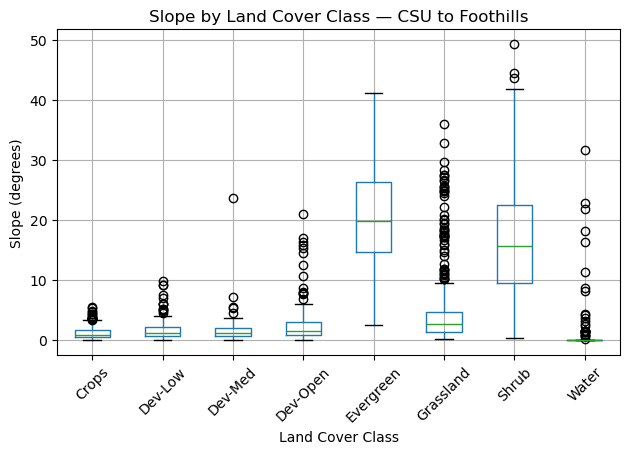

✅ Saved → figures/csu_landcover_vs_slope.png


In [16]:
# Create readable land-cover names

df_slope['landcover_name'] = df_slope['landcover'].astype(int).astype(str).map(nlcd_names)
df_slope = df_slope.dropna(subset=['landcover_name', 'slope'])

# Keep the most common classes so the plot is readable
top_classes = df_slope['landcover_name'].value_counts().head(8).index
df_slope_top = df_slope[df_slope['landcover_name'].isin(top_classes)]

plt.figure(figsize=(12, 6))
df_slope_top.boxplot(
    column='slope',
    by='landcover_name',
    rot=45
)

plt.title('Slope by Land Cover Class — CSU to Foothills')
plt.suptitle('')
plt.xlabel('Land Cover Class')
plt.ylabel('Slope (degrees)')
plt.tight_layout()
plt.savefig('figures/csu_landcover_vs_slope.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved → figures/csu_landcover_vs_slope.png")

In [17]:
# Compare forest and grassland median slopes

forest_classes = ['Deciduous', 'Evergreen', 'Mixed Forest']
grassland_class = 'Grassland'

forest_slope = df_slope_top[df_slope_top['landcover_name'].isin(forest_classes)]['slope']
grassland_slope = df_slope_top[df_slope_top['landcover_name'] == grassland_class]['slope']

print(f"Forest median slope: {forest_slope.median():.2f} degrees")
print(f"Grassland median slope: {grassland_slope.median():.2f} degrees")

if forest_slope.median() > grassland_slope.median():
    print("Forest occurs on steeper slopes than grassland in this sample.")
else:
    print("Forest does not occur on steeper slopes than grassland in this sample.")

Forest median slope: 19.86 degrees
Grassland median slope: 2.59 degrees
Forest occurs on steeper slopes than grassland in this sample.


In [ ]:
# The slope-based boxplot shows that forest classes occur on steeper terrain than grassland in this sample. The median slope for forest is about 19.86 degrees, while the median slope for grassland is about 2.59 degrees. This makes ecological sense for the Front Range because forests are more common in the foothills and mountain areas west of Fort Collins, where slopes are steeper. Grassland is more common on flatter plains and lower-relief areas, so its median slope is much lower.

---
## ✅ You're Done with the Tutorials!

Across the three notebooks you've learned:
- How GEE works, how to authenticate, and how to avoid common pitfalls
- How to load and visualize Landsat imagery (true color, false color)
- How to compute spectral indices (NDVI) and detect change
- How to work with NLCD land cover and count pixels per class
- How to load a DEM, compute slope, and combine it with land cover

These are the exact tools and patterns the Front Range project uses — just at a larger spatial scale and over a 39-year time series. You're ready to start on the analysis notebooks in `notebooks/`.

---
## 💾 Save Your Work

1. Click the **Source Control** icon (left sidebar) — it looks like a branching tree.
2. Stage all changed files with **+**.
3. Write a commit message, e.g. `"Complete notebook 2 NDVI exercises"`.
4. Click **Commit & Push**.

⚠️ Push to **your branch only**, not `main`.